# `process_parcels_Iceland8_bootstrap.m` — Python/Jupyter version

This notebook ports the MATLAB script and its custom dependencies (`spheric_dist`, `dist_geo`, `dist_rx`, `dist_ry`, `dist_du`, and `clear_nan_in_pairs_time`) to Python. It preserves MATLAB pair ordering, block construction, bin edges, sample standard deviation, and `.mat` field names.

Set `input_dir` in the configuration cell for the machine where the parcel NetCDF data are mounted. On meddy the original path is `/meddy/simingzhang/Data/Parcels_data/...`; a Windows example is also shown.

In [1]:
from pathlib import Path
import time
import warnings

import numpy as np
import xarray as xr
from scipy.io import savemat

# ---------------- User configuration (MATLAB defaults) ----------------
case = 'wave'
nparticles = 289
days = 89.5
dt = 3600.0
ini = '_roughsmall'
timerange_matlab = np.arange(1, 1941)  # inclusive MATLAB indices
num_boot = 1000
random_seed = None  # None matches the unseeded MATLAB script; use an int for repeatability

# Use the original Linux path on meddy. Change this if the data are mounted elsewhere.
data_root = Path('/meddy/simingzhang/Data/Parcels_data')
# Windows example: data_root = Path(r'M:\Data\Parcels_data')

input_subdirs = {
    '_grid': 'tranV_onetime_spectukey',
    '_rough': 'tranV_onetime_roughdistr_tukey',
    '_rough_1mon': 'tranV_onetime_roughdistr_tukey',
    '_rough_2mon': 'tranV_onetime_roughdistr_tukey',
    '_roughsmall': 'tranV_onetime_roughsmallregion',
    '_roughsmall_1mon': 'tranV_onetime_roughsmallregion',
    '_roughsmall_2mon': 'tranV_onetime_roughsmallregion',
    '_roughsmall_3mon': 'tranV_onetime_roughsmallregion',
    '_roughLASER': 'tranV_onetime_roughLASER',
    '_roughsmall_rot': 'tranV_onetime_roughsmallregion_rot',
    '_roughsmall_div': 'tranV_onetime_roughsmallregion_div',
    '_cruise': 'tranV_cruise_roughsmallregion',
    '_roughsmall_500m': 'tranV_onetime_roughsmallregion_500m',
    '_rough_500m': 'tranV_onetime_rough_500m',
    '_roughbox200g_500m': 'tranV_onetime_roughbox200g_500m',
    '_roughbox100g_500m': 'tranV_onetime_roughbox100g_500m',
}
if ini not in input_subdirs:
    raise ValueError(f'Unsupported ini={ini!r}')
input_dir = data_root / input_subdirs[ini]
xscale = np.r_[np.arange(2, 19), np.arange(21, 49, 3), np.arange(54, 115, 6)]
if ini in {'_roughsmall_500m', '_rough_500m', '_roughbox200g_500m', '_roughbox100g_500m'}:
    xscale = np.r_[xscale, np.arange(120, 229, 12), np.arange(240, 337, 24)]
fname = input_dir / f'{case}_pars_P{nparticles}T{days:g}days.nc'
sample_output_dir = Path.cwd()  # MATLAB saved the nsamp file in its current directory
print('Input:', fname)

Input: /meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/wave_pars_P289T89.5days.nc


In [2]:
EARTH_RADIUS = 6367442.76  # exact value used by spheric_dist.m

def spheric_dist(lat1, lat2, lon1, lon2):
    lat1, lat2, lon1, lon2 = np.broadcast_arrays(lat1, lat2, lon1, lon2)
    lon_delta = np.abs(lon2 - lon1)
    lon_delta = np.where(lon_delta >= 180.0, 360.0 - lon_delta, lon_delta)
    lat1r, lat2r, lr = np.deg2rad(lat1), np.deg2rad(lat2), np.deg2rad(lon_delta)
    term = (np.sin(lr) * np.cos(lat2r))**2 + (
        np.sin(lat2r) * np.cos(lat1r)
        - np.sin(lat1r) * np.cos(lat2r) * np.cos(lr)
    )**2
    return EARTH_RADIUS * np.arcsin(np.sqrt(np.clip(term, 0.0, 1.0)))

def matlab_time_particle(a, nparticles, name):
    """Return the 2-D array in MATLAB ncread's time-by-particle orientation."""
    a = np.asarray(a).squeeze()
    if a.ndim != 2:
        raise ValueError(f'{name} must be 2-D after squeeze; got {a.shape}')
    if a.shape[1] == nparticles:
        return a
    if a.shape[0] == nparticles:
        return a.T
    raise ValueError(f'Cannot identify particle dimension of {name}: shape={a.shape}')

def pair_quantities(x, y, u, v):
    """Equivalent to MATLAB pdist calls with dist_geo/rx/ry/du."""
    ii, jj = np.triu_indices(x.size, 1)  # same i<j condensed ordering as MATLAB pdist
    mean_lat = 0.5 * (y[ii] + y[jj])
    rx = (x[ii] - x[jj]) * np.cos(np.deg2rad(mean_lat))
    ry = y[ii] - y[jj]
    dist = 111321.0 * np.sqrt(rx**2 + ry**2)
    magr = np.sqrt(rx**2 + ry**2)
    with np.errstate(divide='ignore', invalid='ignore'):
        rx_hat, ry_hat = rx / magr, ry / magr
        dux, duy = u[ii] - u[jj], v[ii] - v[jj]
        dul = dux * rx_hat + duy * ry_hat
        dut = duy * rx_hat - dux * ry_hat
    valid = ~(np.isnan(dist) | np.isnan(dul) | np.isnan(dut))
    return dist[valid], dul[valid], dut[valid]

def matlab_struct(**fields):
    # savemat converts this dict to a scalar MATLAB struct.
    return fields

In [3]:
def run_pipeline(fname=fname):
    started = time.perf_counter()
    tr = np.asarray(timerange_matlab, dtype=int) - 1
    if tr.ndim != 1 or tr.size == 0 or np.any(tr < 0):
        raise ValueError('timerange_matlab must contain positive MATLAB indices')

    with xr.open_dataset(fname, decode_times=False, mask_and_scale=True) as ds:
        lon_all = matlab_time_particle(ds['lon'].values, nparticles, 'lon')
        lat_all = matlab_time_particle(ds['lat'].values, nparticles, 'lat')
        # Read ue/ve because the MATLAB script does, although trajectory velocity is derived from positions.
        _ue = matlab_time_particle(ds['ue'].values, nparticles, 'ue')[tr, :]
        _ve = matlab_time_particle(ds['ve'].values, nparticles, 've')[tr, :]
        lon, lat = lon_all[tr, :], lat_all[tr, :]
        th_rows = []
        for scale in xscale:
            key = f'th{int(scale)}'
            th = matlab_time_particle(ds[key].values, nparticles, key)[tr, :]
            th_rows.append(np.nanmean(th, axis=1))
        Th_all = np.vstack(th_rows)

    # MATLAB forward-difference velocities, including its raw-difference sign convention.
    U = spheric_dist(lat[:-1], lat[:-1], lon[:-1], lon[1:]) / dt * np.sign(lon[1:] - lon[:-1])
    V = spheric_dist(lat[1:], lat[:-1], lon[:-1], lon[:-1]) / dt * np.sign(lat[1:] - lat[:-1])
    lon, lat = lon[:-1], lat[:-1]
    H = np.full_like(V, -520.0, dtype=float)
    T_axis = np.linspace(dt, V.shape[0] * dt, V.shape[0]) / 86400.0

    traj = matlab_struct(trajmat_X=lon, trajmat_Y=lat, trajmat_U=U, trajmat_V=V, H=H, T_axis=T_axis)
    traj_path = fname.with_name(fname.stem + ini + 'traj.mat')
    savemat(traj_path, {'traj': traj}, do_compression=True, oned_as='row')

    # H is always -520 here, so every particle is selected exactly as in id=find(Htraj(i,:)<-500).
    all_dist, all_dul, all_dut = [], [], []
    for i in range(T_axis.size):
        d, dl, dtr = pair_quantities(lon[i], lat[i], U[i], V[i])
        all_dist.append(d); all_dul.append(dl); all_dut.append(dtr)
        if (i + 1) % 100 == 0 or i + 1 == T_axis.size:
            print(f'Pair calculation: {i + 1}/{T_axis.size}')
    dist = np.concatenate(all_dist) if all_dist else np.empty(0)
    dul = np.concatenate(all_dul) if all_dul else np.empty(0)
    dut = np.concatenate(all_dut) if all_dut else np.empty(0)

    first_edge = 1000.0 if ini in {'_roughsmall_500m', '_rough_500m', '_roughbox200g_500m', '_roughbox100g_500m'} else 4000.0
    geometric = first_edge * 1.3 ** np.arange(101)
    first_over = np.flatnonzero(geometric > 600e3)[0]
    dist_bin = np.r_[0.0, geometric[:first_over]]
    dist_axis = 0.5 * (dist_bin[:-1] + dist_bin[1:])

    # MATLAB uses lower-inclusive, upper-exclusive bins.
    pairs_sep = []
    for lo, hi in zip(dist_bin[:-1], dist_bin[1:]):
        mask = (dist >= lo) & (dist < hi)
        pairs_sep.append((dul[mask], dut[mask]))
    nsample = np.array([p[0].size for p in pairs_sep], dtype=float)
    nsamp_path = sample_output_dir / f'{case}P{nparticles}{ini}nsamp.mat'
    savemat(nsamp_path, {'nsample': nsample, 'dist_axis': dist_axis, 'dist_bin': dist_bin}, oned_as='row')

    with warnings.catch_warnings():
        warnings.simplefilter('ignore', category=RuntimeWarning)
        SF2ll = np.array([np.nanmean(dl**2) for dl, _ in pairs_sep])
        SF2tt = np.array([np.nanmean(dtr**2) for _, dtr in pairs_sep])
    SF2 = SF2ll + SF2tt
    Ttot = timerange_matlab.size * 3600.0
    Tscale_tot = dist_axis / np.sqrt(SF2)
    dof = np.ceil(Ttot / Tscale_tot)

    rng = np.random.default_rng(random_seed)
    SF3 = np.full((dist_axis.size, num_boot), np.nan)
    SF1l = np.full((dist_axis.size, num_boot), np.nan)
    for i, (dl, dtr) in enumerate(pairs_sep):
        if dl.size > 10 and np.isfinite(dof[i]) and dof[i] > 0:
            blocksize = int(np.ceil(dl.size / dof[i]))
            numblocks = dl.size // blocksize
            n = numblocks * blocksize
            # C reshape here equals MATLAB reshape(v,[blocksize,numblocks])'.
            blocks_dul = dl[:n].reshape(numblocks, blocksize)
            blocks_dut = dtr[:n].reshape(numblocks, blocksize)
            sf3_blocks = blocks_dul**3 + blocks_dul * blocks_dut**2
            draw = rng.integers(0, numblocks, size=(num_boot, numblocks))
            SF3[i] = sf3_blocks[draw].mean(axis=(1, 2))
            SF1l[i] = blocks_dul[draw].mean(axis=(1, 2))
        print(f'Bootstrap bin: {i + 1}/{dist_axis.size}', end='\r')
    print()
    SF3_mean = np.mean(SF3, axis=1)
    SF3_stderr = np.std(SF3, axis=1, ddof=1)

    output_path = input_dir / f'{case}_pars_P{nparticles}T{timerange_matlab[-1]}{ini}bootstrap.mat'
    savemat(output_path, {
        'SF3': SF3, 'SF3_mean': SF3_mean[:, None], 'SF3_stderr': SF3_stderr[:, None],
        'dof': dof, 'dist_axis': dist_axis, 'dist_bin': dist_bin, 'SF2': SF2,
        'SF2ll': SF2ll, 'SF2tt': SF2tt, 'SF1l': SF1l, 'Th_all': Th_all, 'nsample': nsample,
    }, do_compression=True, oned_as='row')
    print(f'Finished in {(time.perf_counter() - started) / 60:.2f} min')
    print('Trajectory:', traj_path)
    print('Samples:', nsamp_path)
    print('Bootstrap:', output_path)
    return {'traj_path': traj_path, 'nsamp_path': nsamp_path, 'output_path': output_path}


In [4]:
# Full run (the 1940 x 289 pair calculation and 1000 bootstraps can take time).
results = run_pipeline()

Pair calculation: 100/1939
Pair calculation: 200/1939
Pair calculation: 300/1939
Pair calculation: 400/1939
Pair calculation: 500/1939
Pair calculation: 600/1939
Pair calculation: 700/1939
Pair calculation: 800/1939
Pair calculation: 900/1939
Pair calculation: 1000/1939
Pair calculation: 1100/1939
Pair calculation: 1200/1939
Pair calculation: 1300/1939
Pair calculation: 1400/1939
Pair calculation: 1500/1939
Pair calculation: 1600/1939
Pair calculation: 1700/1939
Pair calculation: 1800/1939
Pair calculation: 1900/1939
Pair calculation: 1939/1939
Bootstrap bin: 20/20
Finished in 2.26 min
Trajectory: /meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/wave_pars_P289T89.5days_roughsmalltraj.mat
Samples: /meddy/simingzhang/Analysis/python/China_Israel/waveP289_roughsmallnsamp.mat
Bootstrap: /meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/wave_pars_P289T1940_roughsmallbootstraptest.mat


## MATLAB comparison checklist

For an exact implementation check, set a short `timerange_matlab` and small `num_boot`, run MATLAB and this notebook on the same NetCDF, then compare `dist_bin`, `dist_axis`, `nsample`, `SF2ll`, `SF2tt`, and `Th_all`. Bootstrap draws will not match element-by-element unless both languages are made to consume the same saved resampling indices; their algorithm and sampling distribution are the same.

In [5]:
import scipy.io as sio
import matplotlib.pyplot as plt

In [6]:
test=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/wave_pars_P289T1940_roughsmallbootstraptest.mat')

In [7]:
SF3=np.squeeze(test['SF3_mean'])
dist_axis=np.squeeze(test['dist_axis'])


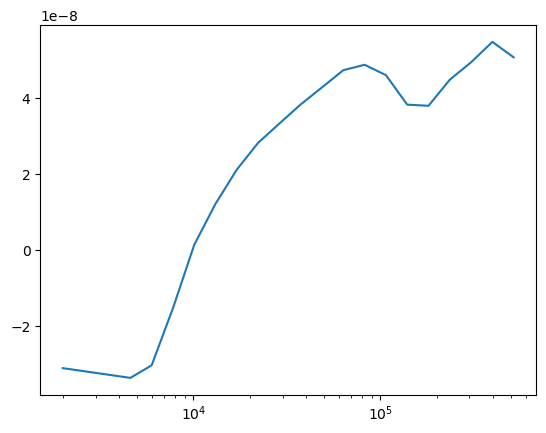

In [10]:
plt.semilogx(dist_axis,SF3/dist_axis)